# Native versus HCIPy: cross-backend validation

**Scientific question.** The repository carries two optical backends: the
*native* backend, written as a transparent reference implementation, and the
*HCIPy* backend, built on the independently implemented
[HCIPy](https://hcipy.org) library. Do both backends realize the same physics
on one small deterministic SCAO profile — and where their numbers differ, are
the residuals fully attributable to known modeling conventions rather than to
physics errors?

**Method.** `shwfs_ao.validation.cross_backend` runs thirteen comparisons
(pupil/throughput, Zernike modes, atmosphere statistics, tip/tilt response,
spot morphology, DM influence and fitting, interaction-matrix identity and
singular spectrum, PSF normalization, Strehl, closed-loop residuals, and
informational runtime/memory) on shared deterministic fixtures. Every metric
carries one of four comparison levels:

| level | meaning |
| --- | --- |
| `exact` | shapes, orderings, identifiers, and signs must be identical |
| `tight_numerical` | conversions and normalized integrals agree to numerical precision |
| `physical_tolerance` | agreement within a documented, justified physical envelope |
| `informational` | recorded but never gating (runtime, memory) |

Independently generated atmospheres are compared **only** through statistical
diagnostics: equal seeds do not imply equal realizations across libraries.
This notebook only *reads* the accepted baseline packaged with the library;
baseline candidates and acceptance run through
`scripts/generate_cross_backend_candidate.py`, never through a notebook.

In [1]:
from shwfs_ao.validation.cross_backend import CrossBackendConfig

config = CrossBackendConfig()
print(f"comparison config hash: {config.config_hash[:16]}")
print(f"root seed:              {config.root_seed}")
config

comparison config hash: 1e77e856c1f0e4d2
root seed:              118


CrossBackendConfig(root_seed=118, telescope_diameter_m=1.0, pupil_pixels=48, lenslets_across=3, min_fill_fraction=0.3, wfs_wavelength_m=7e-07, science_wavelength_m=7e-07, spot_sampling_px=4.0, n_actuators_across=3, coupling_width_pitch=0.35, stroke_limit_nm=20000.0, photons_per_subap_frame=20000.0, static_aberration_rms_m=6e-08, tilt_amplitude_px=0.8, r0_m=0.15, outer_scale_m=20.0, wind_m_per_s=(5.0, 0.0), atmosphere_realizations=4, structure_function_lags_px=(2, 4), frame_rate_hz=500.0, loop_r0_m=0.45, loop_steps=4, loop_gain=0.5, psf_pad_factor=4, hcipy_psf_pixels_per_resolution_element=5.0, hcipy_psf_radius_resolution_elements=12.0, runtime_repeats=3)

In [2]:
from shwfs_ao.validation.cross_backend import run_cross_backend_report

report = run_cross_backend_report(config)
print(f"comparisons: {len(report['comparisons'])}")
print(f"hcipy:       {report['environment']['hcipy_version']}")
print(f"numpy:       {report['environment']['numpy_version']}")

comparisons: 13
hcipy:       0.7.0
numpy:       2.5.0


In [3]:
import pandas as pd


def criterion_text(criterion):
    kind = criterion["type"]
    if kind == "equals":
        return f"= {criterion['expected']!r}"
    if kind == "abs_tolerance":
        return f"{criterion['expected']:g} \u00b1 {criterion['tolerance']:g}"
    if kind == "range":
        return f"[{criterion['low']:g}, {criterion['high']:g}]"
    return "recorded only"


table = pd.DataFrame(
    {
        "comparison": comparison["comparison_kind"],
        "metric": metric["name"],
        "level": metric["level"],
        "value": metric["value"],
        "accepted": criterion_text(metric["pass_criterion"]),
        "units": metric["units"],
    }
    for comparison in report["comparisons"]
    for metric in comparison["metrics"]
)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 44):
    display(table)

,comparison,metric,level,value,accepted,units
0,pupil_mask_and_throughput,mask_round_trip_identical,exact,True,= True,boolean
1,pupil_mask_and_throughput,illuminated_sample_count,exact,1716,= 1716,samples
2,pupil_mask_and_throughput,native_mean_window_capture,tight_numerical,1.0,1 ± 1e-09,fraction
3,pupil_mask_and_throughput,hcipy_mean_window_capture,physical_tolerance,0.956785,"[0.9, 1]",fraction
4,zernike_modes,tip_x_alignment_defect,tight_numerical,0.0,0 ± 1e-09,1 - |correlation|
5,zernike_modes,tip_x_relative_sign,exact,1,= 1,sign
6,zernike_modes,tip_y_alignment_defect,tight_numerical,0.0,0 ± 1e-09,1 - |correlation|
7,zernike_modes,tip_y_relative_sign,exact,1,= 1,sign
8,zernike_modes,defocus_alignment_defect,tight_numerical,0.0,0 ± 1e-09,1 - |correlation|
9,zernike_modes,defocus_relative_sign,exact,1,= 1,sign


In [4]:
from shwfs_ao.validation.regression import (
    evaluate_report_against_baseline,
    load_cross_backend_baseline,
)

baseline = load_cross_backend_baseline()
failures = evaluate_report_against_baseline(report, baseline)
for failure in failures:
    print(failure)
assert not failures, "cross-backend report violates the accepted baseline"
acceptance = baseline["acceptance"]
print("all gating comparisons satisfy the accepted baseline tolerances")
print(f"baseline reference:  {acceptance['review_reference']}")
print(f"baseline commit:     {baseline['generator']['source_commit'][:12]}")
print(f"baseline accepted:   {acceptance['accepted_at_utc'][:10]}")

all gating comparisons satisfy the accepted baseline tolerances
baseline reference:  AO-REF-018
baseline commit:     4a97daabe950
baseline accepted:   2026-07-17


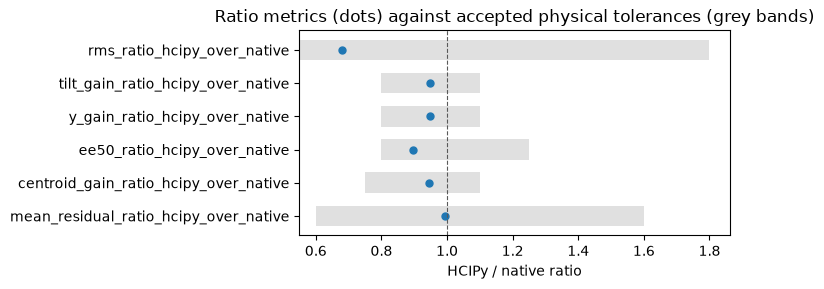

In [5]:
import matplotlib.pyplot as plt
import numpy as np

RATIO_METRICS = (
    ("atmosphere_statistics", "rms_ratio_hcipy_over_native"),
    ("wfs_tip_tilt_response", "tilt_gain_ratio_hcipy_over_native"),
    ("wfs_tip_tilt_response", "y_gain_ratio_hcipy_over_native"),
    ("lenslet_spot_morphology", "ee50_ratio_hcipy_over_native"),
    ("lenslet_spot_morphology", "centroid_gain_ratio_hcipy_over_native"),
    ("closed_loop_residual", "mean_residual_ratio_hcipy_over_native"),
)
metric_index = {
    (comparison["comparison_kind"], metric["name"]): metric
    for comparison in report["comparisons"]
    for metric in comparison["metrics"]
}

figure, axis = plt.subplots(figsize=(7.5, 3.0))
positions = np.arange(len(RATIO_METRICS))[::-1]
for position, key in zip(positions, RATIO_METRICS):
    metric = metric_index[key]
    low = metric["pass_criterion"]["low"]
    high = metric["pass_criterion"]["high"]
    axis.barh(position, high - low, left=low, height=0.62, color="0.88")
    axis.plot(metric["value"], position, "o", color="C0", markersize=5)
axis.axvline(1.0, color="0.35", linewidth=0.8, linestyle="--")
axis.set_yticks(positions)
axis.set_yticklabels(name for _, name in RATIO_METRICS)
axis.set_xlabel("HCIPy / native ratio")
axis.set_title(
    "Ratio metrics (dots) against accepted physical tolerances (grey bands)"
)
figure.tight_layout()
plt.show()

## Interpretation

- **Exact layer.** Pupil masks, illuminated-sample inventories, actuator and
  measurement-row identities, interaction-matrix shapes, ranks, and tip/tilt
  signs are identical because both backends consume the same repository-owned
  geometry, identifiers, and calibration chain; only the optical propagation
  differs.
- **Tight numerical layer.** Zernike-mode alignment, in-pupil DM influence
  functions, DM least-squares fitting residuals, and PSF flux normalization
  agree to numerical precision (relative differences at or below
  $10^{-6}$, most below $10^{-9}$): shared analytic definitions evaluated on
  one grid must not disagree.
- **Physical tolerance layer.** The remaining differences are percent-level
  and attributed in each comparison record: the HCIPy Shack-Hartmann
  propagates the full field onto pupil-sampled focal blocks (finite windows
  lose a few percent of each spot and admit neighbouring-lenslet crosstalk),
  while the native path propagates each lenslet alone on a padded canvas;
  focal-grid sampling differs between the science propagators; and the HCIPy
  DM keeps its analytic Gaussian tail outside the pupil. Strehl ratios agree
  to better than $10^{-4}$ and both track the Maréchal expectation.
- **Statistics-only layer.** Atmosphere realizations from the two libraries
  are never compared pointwise; masked RMS and small-lag structure-function
  growth agree within the wide finite-sample envelopes, both sitting below
  the pure Kolmogorov 5/3 lag scaling as expected for a finite outer scale.

## Limitations

- One small deterministic profile (48 px pupil, 3×3 lenslets, 3×3 actuators,
  four-step loop) keeps the suite CI-fast; the tolerance envelopes are
  justified for this configuration only and are not universal claims.
- Atmosphere statistics rest on four realizations per backend, so the
  acceptance bands are deliberately wide (more than three times the observed
  realization scatter).
- Runtime and memory entries are informational: they depend on the executing
  platform and never gate correctness CI.
- **No claim of complete equivalence is made.** The suite demonstrates that
  the native backend is a faithful transparent reference and HCIPy an
  independently implemented physical backend whose residual differences are
  understood; it does not prove the backends interchangeable outside the
  compared regime.